In [2]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from joblib import parallel_backend
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("diamonds.csv")
df.head()

,ID,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Shape: (53940, 11)

Columns:
['ID', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

Missing values:
ID         0
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Data types:
ID           int64
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object


In [5]:
df = df.drop(columns=["ID"], errors="ignore")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
# Zero is not a valid diamond dimension; impute these values later.
df[["x", "y", "z"]] = df[["x", "y", "z"]].replace(0, float("nan"))
print(df[["x", "y", "z"]].isnull().sum())

x     8
y     7
z    20
dtype: int64


## Exploratory Data Analysis (EDA)

These visualizations explore the target distribution and the relationships between diamond attributes and price before modeling.

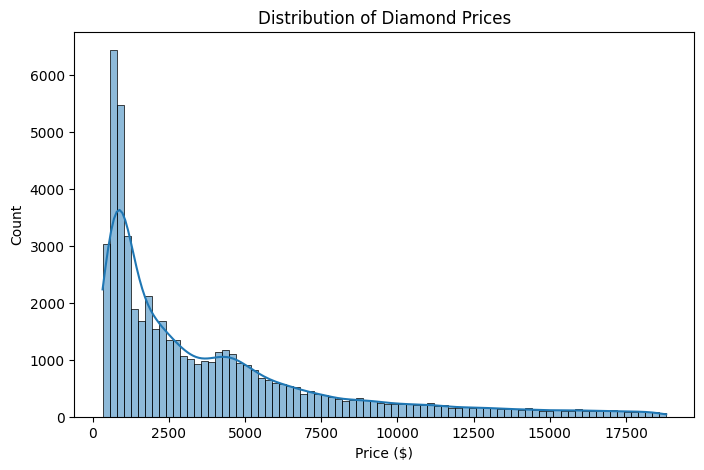

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of Diamond Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

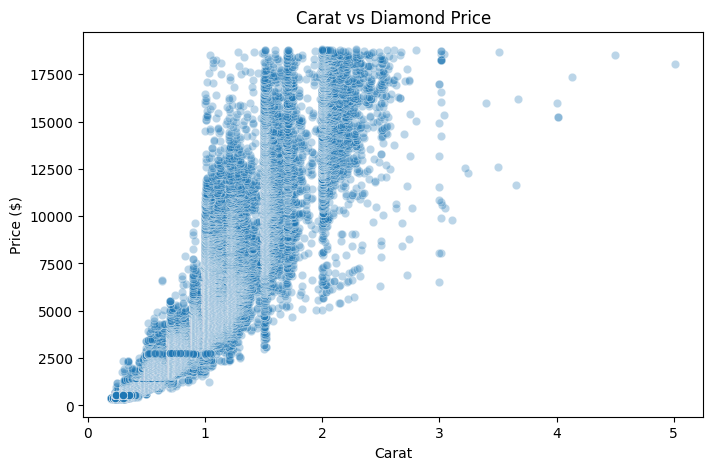

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="carat", y="price", alpha=0.3)
plt.title("Carat vs Diamond Price")
plt.xlabel("Carat")
plt.ylabel("Price ($)")
plt.show()

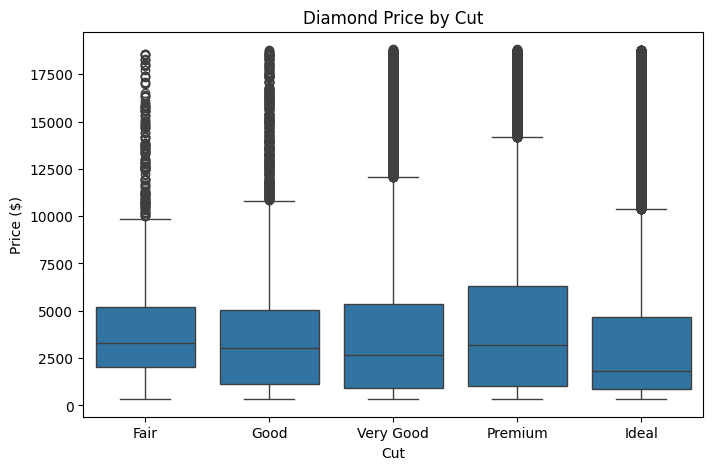

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="cut",
    y="price",
    order=["Fair", "Good", "Very Good", "Premium", "Ideal"],
)
plt.title("Diamond Price by Cut")
plt.xlabel("Cut")
plt.ylabel("Price ($)")
plt.show()

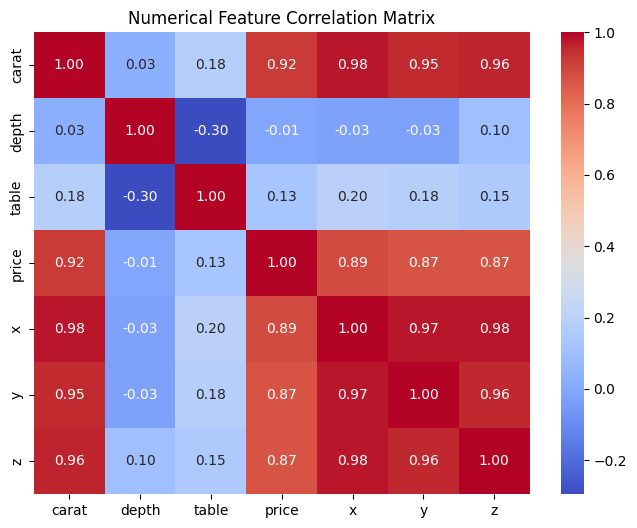

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)
plt.title("Numerical Feature Correlation Matrix")
plt.show()

In [11]:
X = df.drop(columns="price")
y = df["price"]

categorical_features = ["cut", "color", "clarity"]
numerical_features = ["carat", "depth", "table", "x", "y", "z"]

In [12]:
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

In [13]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OrdinalEncoder(
                categories=[cut_order, color_order, clarity_order],
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipeline, categorical_features),
        ("numerical", numerical_pipeline, numerical_features),
    ]
)

The categorical variables are ordinal because their categories have a meaningful quality ranking. Therefore, OrdinalEncoder is used with explicitly defined category orders.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 43152
Testing rows: 10788


## Mean Baseline

The baseline predicts the mean training price for every test example. A useful model should outperform it on every error metric.

In [15]:
baseline_prediction = y_train.mean()
baseline_predictions = [baseline_prediction] * len(y_test)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = mean_squared_error(y_test, baseline_predictions) ** 0.5
baseline_r2 = r2_score(y_test, baseline_predictions)

print(f"Baseline MAE:  ${baseline_mae:,.2f}")
print(f"Baseline RMSE: ${baseline_rmse:,.2f}")
print(f"Baseline R2:   {baseline_r2:.4f}")

Baseline MAE:  $3,020.51
Baseline RMSE: $3,987.22
Baseline R2:   -0.0001


In [16]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                max_iter=300,
                learning_rate=0.08,
                max_leaf_nodes=31,
                l2_regularization=0.1,
                random_state=42,
            ),
        ),
    ]
)

In [17]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [18]:
predictions = model_pipeline.predict(X_test)
predictions[:10]

array([ 590.73707847, 2357.34185979, 1199.34367156, 1313.81733248,
       9688.61279224, 3697.15495623, 1838.03748686, 1804.60353879,
       2174.4990055 , 5792.42210322])

In [19]:
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  $279.77
RMSE: $538.22
R²:   0.9818


In [20]:
parameter_distributions = {
    "model__max_iter": [200, 300, 400, 500],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__l2_regularization": [0.0, 0.01, 0.1, 1.0],
    "model__min_samples_leaf": [10, 20, 30],
}

In [21]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=parameter_distributions,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

with parallel_backend("threading"):
    search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [22]:
print("Best hyperparameters:")
print(search.best_params_)

print(f"\nBest cross-validation RMSE: ${-search.best_score_:,.2f}")

Best hyperparameters:
{'model__min_samples_leaf': 10, 'model__max_leaf_nodes': 63, 'model__max_iter': 300, 'model__learning_rate': 0.03, 'model__l2_regularization': 1.0}

Best cross-validation RMSE: $541.84


In [23]:
best_model = search.best_estimator_

tuned_predictions = best_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_rmse = mean_squared_error(y_test, tuned_predictions) ** 0.5
tuned_r2 = r2_score(y_test, tuned_predictions)

print("Tuned Model Results")
print(f"MAE:  ${tuned_mae:,.2f}")
print(f"RMSE: ${tuned_rmse:,.2f}")
print(f"R²:   {tuned_r2:.4f}")

Tuned Model Results
MAE:  $278.01
RMSE: $537.22
R²:   0.9818


## Model Comparison

In [24]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Mean Baseline",
            "HistGradientBoosting",
            "Tuned HistGradientBoosting",
        ],
        "MAE": [baseline_mae, mae, tuned_mae],
        "RMSE": [baseline_rmse, rmse, tuned_rmse],
        "R2": [baseline_r2, r2, tuned_r2],
    }
)

comparison.style.format({"MAE": "${:,.2f}", "RMSE": "${:,.2f}", "R2": "{:.4f}"})

,Model,MAE,RMSE,R2
0,Mean Baseline,"$3,020.51","$3,987.22",-0.0001
1,HistGradientBoosting,$279.77,$538.22,0.9818
2,Tuned HistGradientBoosting,$278.01,$537.22,0.9818


In [25]:
new_diamond = pd.DataFrame(
    [{
        "carat": 1.00,
        "cut": "Ideal",
        "color": "G",
        "clarity": "VS2",
        "depth": 61.5,
        "table": 56.0,
        "x": 6.40,
        "y": 6.42,
        "z": 3.95,
    }]
)

predicted_price = best_model.predict(new_diamond)

print(f"Predicted diamond price: ${predicted_price[0]:,.2f}")

Predicted diamond price: $6,308.68


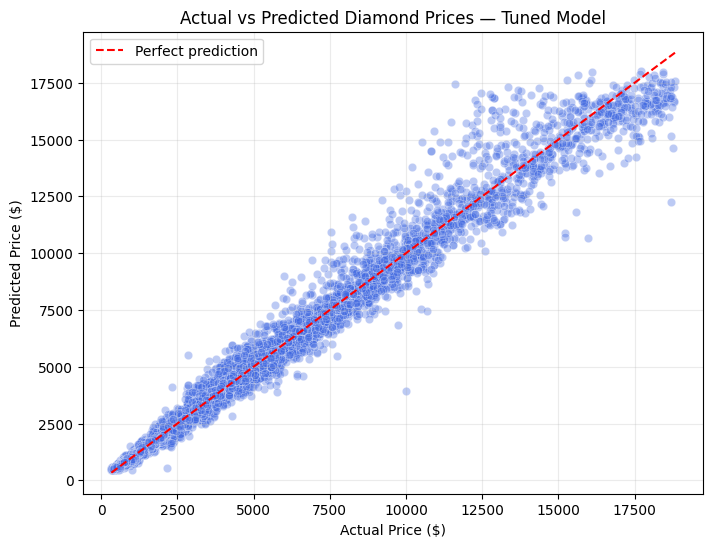

In [26]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=tuned_predictions,
    alpha=0.35,
    color="royalblue",
)

lowest = min(y_test.min(), tuned_predictions.min())
highest = max(y_test.max(), tuned_predictions.max())

plt.plot(
    [lowest, highest],
    [lowest, highest],
    color="red",
    linestyle="--",
    label="Perfect prediction",
)

plt.title("Actual vs Predicted Diamond Prices — Tuned Model")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

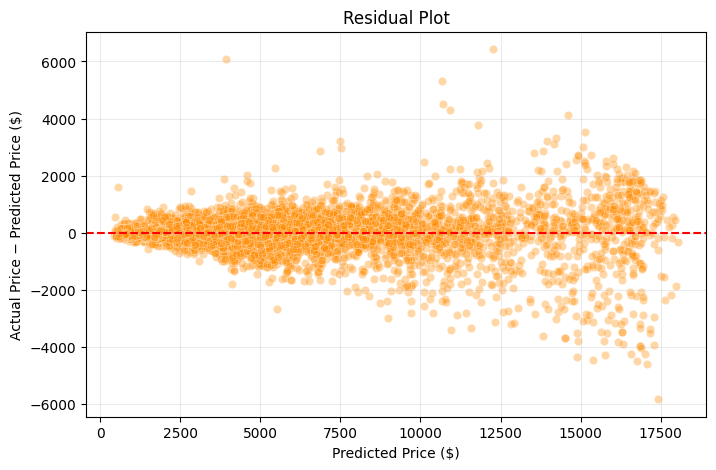

In [27]:
residuals = y_test - tuned_predictions

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=tuned_predictions,
    y=residuals,
    alpha=0.35,
    color="darkorange",
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Actual Price − Predicted Price ($)")
plt.grid(alpha=0.25)
plt.show()

## Conclusion
This project developed a diamond price prediction model using HistGradientBoostingRegressor. Exploratory data analysis, missing-value handling and ordinal encoding were performed before model training.

The initial model achieved an MAE of $279.77, an RMSE of $538.22 and an R² of 0.9818 on the held-out test set.

RandomizedSearchCV with five-fold cross-validation was used for hyperparameter tuning. The tuned model achieved an MAE of $278.01 and an RMSE of $537.22, representing modest improvements over the initial model.

Both models substantially outperformed the mean-price baseline. The results demonstrate the effectiveness of histogram-based gradient boosting for predicting prices in this dataset.

Future work could explore alternative encoding strategies, feature importance and model performance across different diamond price ranges.
